In [1]:
import pandas as pd
import numpy as np

ohlcv = pd.read_csv("silver_daily_ohlcv_2000_2025.csv")

ohlcv['Date'] = pd.to_datetime(ohlcv['Date'])

ohlcv.head()

,Date,Open,High,Low,Close,Adj_Close,Volume,VWAP,Returns_Pct,Log_Returns,Dollar_Change,Intraday_Range,Intraday_Range_Pct
0,2000-01-03,5.1962,5.1962,5.1884,5.1910,5.1910,36286,5.1919,-0.1729,-0.001731,-0.0090,0.0078,0.1511
1,2000-01-04,5.1084,5.1084,5.0848,5.0980,5.0980,35819,5.0971,-1.7916,-0.018079,-0.0930,0.0236,0.4649
2,2000-01-05,5.1388,5.1464,5.1388,5.1412,5.1412,38844,5.1421,0.8480,0.008444,0.0432,0.0076,0.1472
3,2000-01-06,5.2123,5.2291,5.2123,5.2239,5.2239,24445,5.2218,1.6076,0.015948,0.0826,0.0168,0.3225
4,2000-01-07,5.2766,5.2832,5.2766,5.2779,5.2779,40020,5.2792,1.0344,0.010291,0.0540,0.0066,0.1251


In [2]:
ohlcv['SMA20'] = ohlcv['Close'].rolling(20).mean()

ohlcv['SMA50'] = ohlcv['Close'].rolling(50).mean()

ohlcv['SMA200'] = ohlcv['Close'].rolling(200).mean()

In [3]:
ohlcv['EMA12'] = ohlcv['Close'].ewm(span=12).mean()

ohlcv['EMA26'] = ohlcv['Close'].ewm(span=26).mean()

In [4]:
ohlcv['MACD'] = ohlcv['EMA12'] - ohlcv['EMA26']

In [5]:
delta = ohlcv['Close'].diff()

gain = delta.where(delta > 0, 0)

loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()

avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

ohlcv['RSI'] = 100 - (100 / (1 + rs))

In [6]:
rolling_mean = ohlcv['Close'].rolling(20).mean()

rolling_std = ohlcv['Close'].rolling(20).std()

ohlcv['BB_Upper'] = rolling_mean + 2*rolling_std

ohlcv['BB_Lower'] = rolling_mean - 2*rolling_std

In [7]:
high_low = ohlcv['High'] - ohlcv['Low']

high_close = abs(
    ohlcv['High'] - ohlcv['Close'].shift()
)

low_close = abs(
    ohlcv['Low'] - ohlcv['Close'].shift()
)

ranges = pd.concat(
    [high_low, high_close, low_close],
    axis=1
)

true_range = ranges.max(axis=1)

ohlcv['ATR'] = true_range.rolling(14).mean()

In [8]:
ohlcv['Lag_1'] = ohlcv['Close'].shift(1)

ohlcv['Lag_3'] = ohlcv['Close'].shift(3)

ohlcv['Lag_7'] = ohlcv['Close'].shift(7)

ohlcv['Lag_14'] = ohlcv['Close'].shift(14)

In [9]:
ohlcv['Rolling_Mean_7'] = (
    ohlcv['Close']
    .rolling(7)
    .mean()
)

ohlcv['Rolling_STD_7'] = (
    ohlcv['Close']
    .rolling(7)
    .std()
)

In [10]:
ohlcv.head()

,Date,Open,High,Low,Close,Adj_Close,Volume,VWAP,Returns_Pct,Log_Returns,...,RSI,BB_Upper,BB_Lower,ATR,Lag_1,Lag_3,Lag_7,Lag_14,Rolling_Mean_7,Rolling_STD_7
0,2000-01-03,5.1962,5.1962,5.1884,5.1910,5.1910,36286,5.1919,-0.1729,-0.001731,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-04,5.1084,5.1084,5.0848,5.0980,5.0980,35819,5.0971,-1.7916,-0.018079,...,NaN,NaN,NaN,NaN,5.1910,NaN,NaN,NaN,NaN,NaN
2,2000-01-05,5.1388,5.1464,5.1388,5.1412,5.1412,38844,5.1421,0.8480,0.008444,...,NaN,NaN,NaN,NaN,5.0980,NaN,NaN,NaN,NaN,NaN
3,2000-01-06,5.2123,5.2291,5.2123,5.2239,5.2239,24445,5.2218,1.6076,0.015948,...,NaN,NaN,NaN,NaN,5.1412,5.191,NaN,NaN,NaN,NaN
4,2000-01-07,5.2766,5.2832,5.2766,5.2779,5.2779,40020,5.2792,1.0344,0.010291,...,NaN,NaN,NaN,NaN,5.2239,5.098,NaN,NaN,NaN,NaN


In [11]:
ohlcv.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume', 'VWAP',
       'Returns_Pct', 'Log_Returns', 'Dollar_Change', 'Intraday_Range',
       'Intraday_Range_Pct', 'SMA20', 'SMA50', 'SMA200', 'EMA12', 'EMA26',
       'MACD', 'RSI', 'BB_Upper', 'BB_Lower', 'ATR', 'Lag_1', 'Lag_3', 'Lag_7',
       'Lag_14', 'Rolling_Mean_7', 'Rolling_STD_7'],
      dtype='object')

In [12]:
ohlcv.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj_Close,0
Volume,0
VWAP,0
Returns_Pct,0
Log_Returns,0


In [13]:
ohlcv = ohlcv.dropna()

In [14]:
ohlcv.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj_Close,0
Volume,0
VWAP,0
Returns_Pct,0
Log_Returns,0


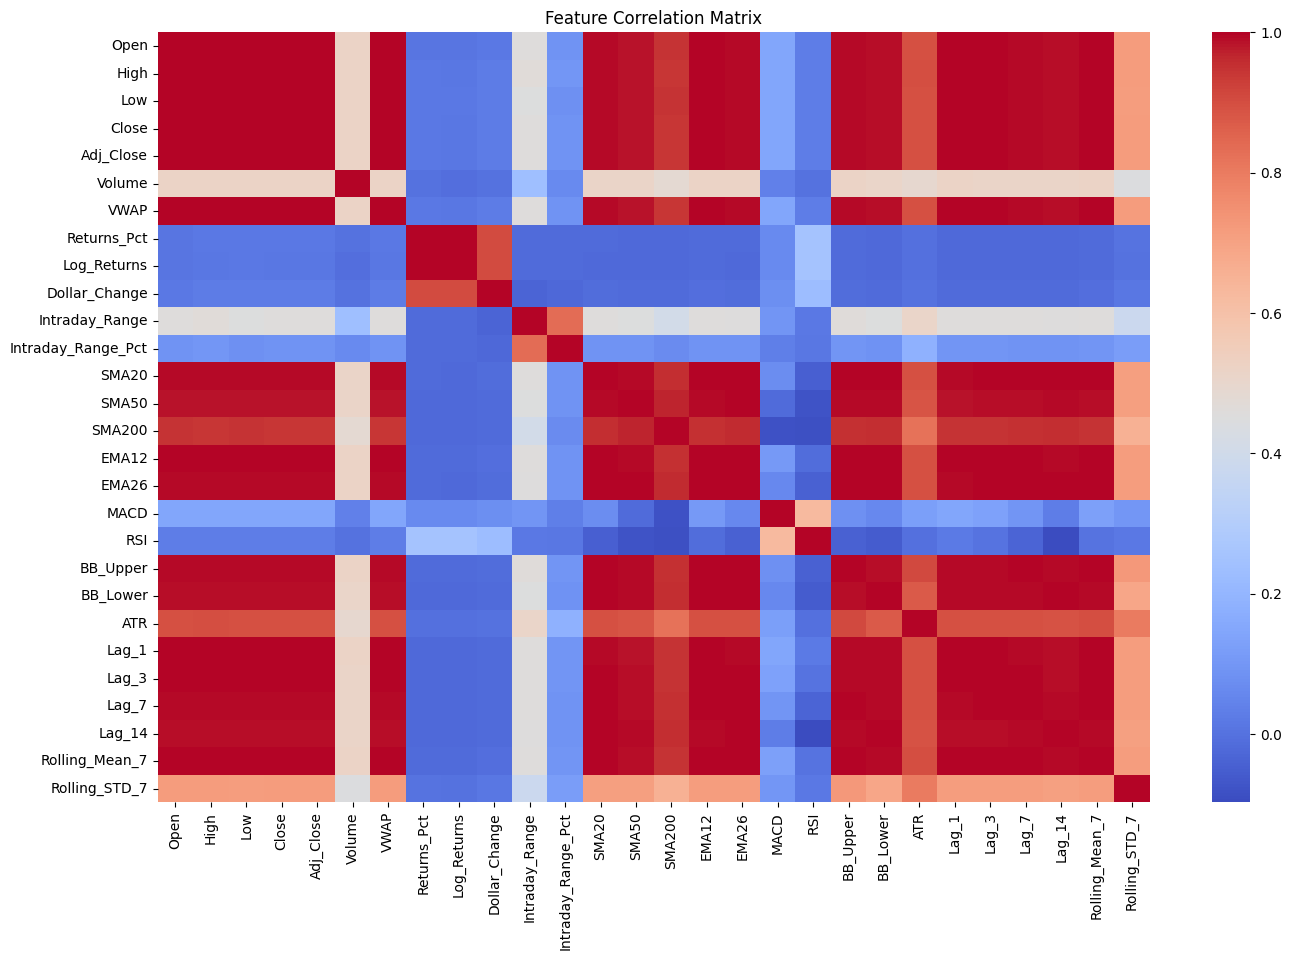

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,10))

sns.heatmap(
    ohlcv.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Feature Correlation Matrix")
plt.show()

In [16]:
ohlcv.to_csv(
    "feature_engineered.csv",
    index=False
)

# Feature Engineering Insights

### 1. Strong Price-Based Relationships
The heatmap shows a very strong positive correlation between Open, High, Low, Close, Adj_Close, and VWAP variables. This indicates that silver prices move consistently across different price measures and confirms the quality of the historical market data.

### 2. Moving Averages Capture Market Trends
SMA20, SMA50, SMA200, EMA12, and EMA26 exhibit strong positive correlations with the silver price variables. These indicators effectively capture short-term and long-term market trends, making them valuable forecasting features.

### 3. Lag Features Show High Predictive Power
Lag_1, Lag_3, Lag_7, and Lag_14 demonstrate strong correlations with current prices. This suggests that historical silver prices have a significant influence on future price movements, validating the use of time-series forecasting models.

### 4. Volatility Indicators Add Risk Information
ATR, Bollinger Upper Band, Bollinger Lower Band, and Rolling_STD_7 provide additional information about market volatility. These features help models understand periods of increased uncertainty and price fluctuations.

### 5. Momentum Indicators Capture Market Sentiment
MACD and RSI introduce momentum-based information that is not directly available from raw prices. These indicators can help identify trend reversals, bullish momentum, and bearish momentum in the silver market.

### 6. Rolling Statistics Improve Pattern Recognition
Rolling_Mean_7 and Rolling_STD_7 successfully summarize short-term market behavior and reduce noise in daily price movements. These features can improve model stability and forecasting accuracy.

### 7. Feature Diversity Improves Forecasting Capability
The engineered dataset now contains trend indicators, momentum indicators, volatility indicators, lag variables, and rolling statistical measures. This diverse feature set provides a comprehensive representation of silver market dynamics.

### Conclusion
Feature engineering significantly enhanced the predictive information available in the dataset. The generated features capture trend, momentum, volatility, and historical dependencies, creating a strong foundation for ARIMA, Prophet, XGBoost, LSTM, and Ensemble forecasting models.

In [17]:
ohlcv['Market_Regime'] = np.where(
    ohlcv['Close'] > ohlcv['SMA200'],
    'Bull',
    'Bear'
)

In [18]:
ohlcv['Momentum_5'] = (
    ohlcv['Close'] -
    ohlcv['Close'].shift(5)
)

In [19]:
ohlcv['Momentum_5_Pct'] = (
    (ohlcv['Close'] - ohlcv['Close'].shift(5))
    / ohlcv['Close'].shift(5)
) * 100

In [20]:
ohlcv['Momentum_5'] = ohlcv['Close'] - ohlcv['Close'].shift(5)

ohlcv['Momentum_10'] = ohlcv['Close'] - ohlcv['Close'].shift(10)

ohlcv['Momentum_20'] = ohlcv['Close'] - ohlcv['Close'].shift(20)

In [21]:
X = ohlcv.drop(['Date', 'Close'], axis=1)

y = ohlcv['Close']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [23]:
ohlcv['Market_Regime'] = np.where(
    ohlcv['Close'] > ohlcv['SMA200'],
    1,
    0
)

In [24]:
X = ohlcv.drop(['Date','Close'], axis=1)

y = ohlcv['Close']

In [25]:
ohlcv = ohlcv.dropna()

X = ohlcv.drop(['Date', 'Close'], axis=1)

y = ohlcv['Close']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

In [26]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [27]:
importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

           Feature  Importance
3        Adj_Close    0.615962
5             VWAP    0.239976
2              Low    0.054441
0             Open    0.049067
1             High    0.028177
21           Lag_1    0.008589
25  Rolling_Mean_7    0.001845
23           Lag_7    0.000695
14           EMA12    0.000616
18        BB_Upper    0.000178


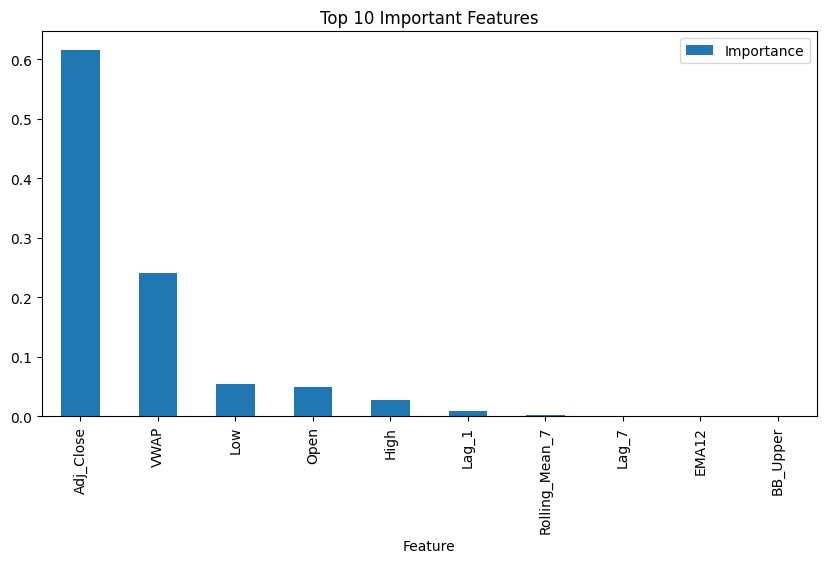

In [28]:
import matplotlib.pyplot as plt

feature_importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='bar',
    figsize=(10,5)
)

plt.title("Top 10 Important Features")
plt.show()

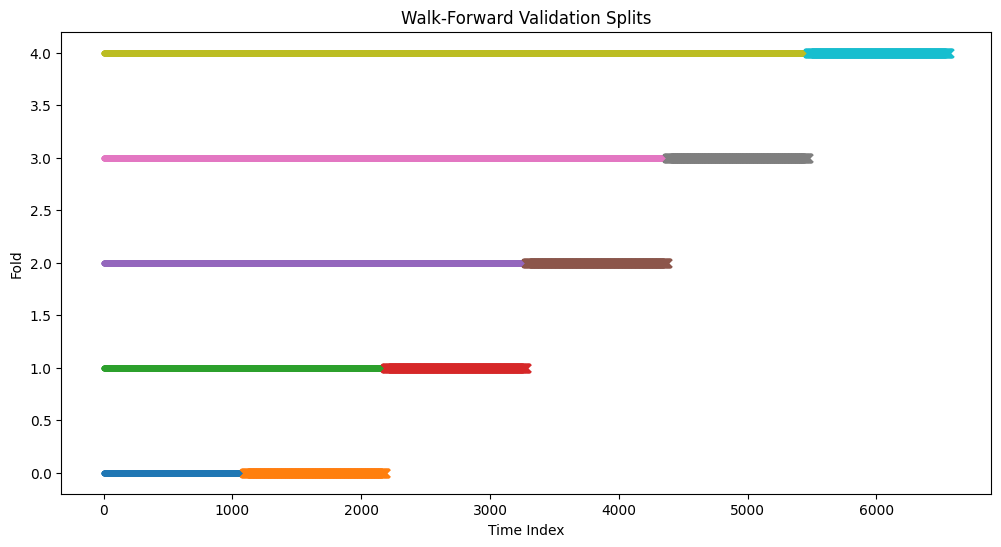

In [29]:
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt

tscv = TimeSeriesSplit(n_splits=5)

plt.figure(figsize=(12,6))

for i, (train_index, test_index) in enumerate(tscv.split(X)):

    plt.scatter(
        train_index,
        [i]*len(train_index),
        label=f"Train Fold {i+1}",
        marker='.'
    )

    plt.scatter(
        test_index,
        [i]*len(test_index),
        label=f"Test Fold {i+1}",
        marker='x'
    )

plt.title("Walk-Forward Validation Splits")
plt.xlabel("Time Index")
plt.ylabel("Fold")
plt.show()

In [30]:
import pandas as pd

macro = pd.read_csv("silver_macroeconomic_monthly.csv")

macro.head()

,Date,Silver_Price_USD,Gold_Price_USD,Silver_Gold_Ratio,Fed_Funds_Rate,US_10Y_Yield,Real_Interest_Rate,US_CPI_Index,US_CPI_YoY_Pct,DXY_Index,Crude_Oil_WTI,VIX_Index,US_M2_Supply_Trillions,India_Repo_Rate,USD_INR,Silver_Price_INR_Per_Kg,Global_PMI,US_Unemployment_Rate,ETF_Silver_Holdings_MOz
0,2000-01-01,5.20,344.55,66.26,5.47,7.18,1.42,169.0,4.05,99.23,22.65,20.52,4.624,5.96,43.10,7206.0,53.0,3.5,0.0
1,2000-02-01,5.12,370.80,72.35,5.46,7.59,3.81,169.8,1.65,100.90,30.87,9.00,4.638,6.10,43.26,7128.0,47.7,4.8,0.0
2,2000-03-01,5.08,357.56,70.46,5.44,7.29,0.67,170.4,4.77,101.19,33.75,9.85,4.668,5.79,44.02,7183.0,46.3,3.5,0.0
3,2000-04-01,5.03,276.90,55.10,5.35,7.74,0.39,171.1,4.96,101.42,26.43,17.03,4.701,5.98,43.71,7061.0,50.4,4.8,0.0
4,2000-05-01,4.98,311.31,62.58,5.29,7.28,-0.40,171.5,5.69,101.97,26.05,9.00,4.730,6.49,44.44,7108.0,52.5,5.0,0.0


In [31]:
macro.columns

Index(['Date', 'Silver_Price_USD', 'Gold_Price_USD', 'Silver_Gold_Ratio',
       'Fed_Funds_Rate', 'US_10Y_Yield', 'Real_Interest_Rate', 'US_CPI_Index',
       'US_CPI_YoY_Pct', 'DXY_Index', 'Crude_Oil_WTI', 'VIX_Index',
       'US_M2_Supply_Trillions', 'India_Repo_Rate', 'USD_INR',
       'Silver_Price_INR_Per_Kg', 'Global_PMI', 'US_Unemployment_Rate',
       'ETF_Silver_Holdings_MOz'],
      dtype='object')

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

macro[['DXY_Norm',
       'Fed_Norm',
       'VIX_Norm']] = scaler.fit_transform(
    macro[['DXY_Index',
           'Fed_Funds_Rate',
           'VIX_Index']]
)

macro['Impact_Score'] = (
    0.4 * macro['DXY_Norm']
    + 0.3 * macro['Fed_Norm']
    + 0.3 * macro['VIX_Norm']
)

macro[['Date', 'Impact_Score']].head()

,Date,Impact_Score
0,2000-01-01,0.575928
1,2000-02-01,0.548162
2,2000-03-01,0.555701
3,2000-04-01,0.587295
4,2000-05-01,0.553074


In [33]:
ohlcv['Trend_Strength'] = (
    abs(ohlcv['SMA20'] - ohlcv['SMA50'])
    / ohlcv['SMA50']
) * 100

In [34]:
ohlcv[['SMA20','SMA50','Trend_Strength']].head()

,SMA20,SMA50,Trend_Strength
219,4.755535,4.765650,0.212248
220,4.771310,4.763626,0.161306
221,4.783560,4.758914,0.517891
222,4.790485,4.753302,0.782256
223,4.799790,4.747024,1.111560


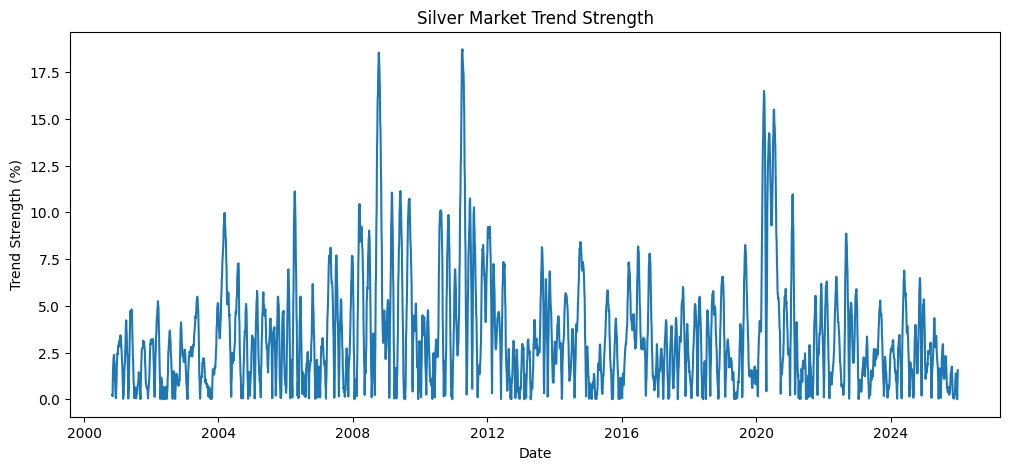

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    ohlcv['Date'],
    ohlcv['Trend_Strength']
)

plt.title("Silver Market Trend Strength")
plt.xlabel("Date")
plt.ylabel("Trend Strength (%)")

plt.show()

In [36]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

ohlcv[['ATR_Norm', 'Vol_Norm']] = scaler.fit_transform(
    ohlcv[['ATR', 'Rolling_STD_7']]
)

ohlcv['Risk_Score'] = (
    0.6 * ohlcv['ATR_Norm']
    + 0.4 * ohlcv['Vol_Norm']
)

ohlcv[['Risk_Score']].head()

,Risk_Score
219,0.015919
220,0.016809
221,0.017930
222,0.018759
223,0.014168


In [37]:
ohlcv['Risk_Level'] = pd.cut(
    ohlcv['Risk_Score'],
    bins=[0, 0.33, 0.66, 1],
    labels=['Low', 'Medium', 'High']
)

ohlcv[['Risk_Score', 'Risk_Level']].tail()

,Risk_Score,Risk_Level
6778,0.336411,Medium
6779,0.340222,Medium
6780,0.358140,Medium
6781,0.377887,Medium
6782,0.360966,Medium


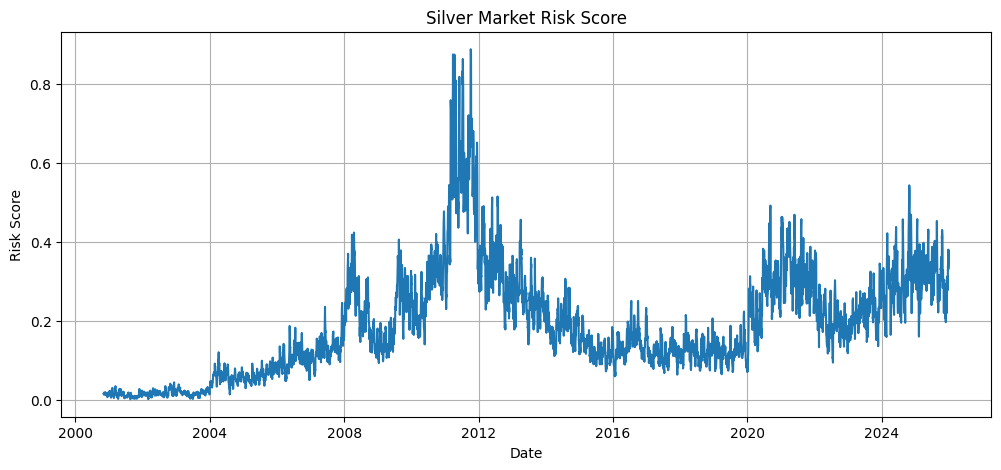

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    ohlcv['Date'],
    ohlcv['Risk_Score']
)

plt.title('Silver Market Risk Score')
plt.xlabel('Date')
plt.ylabel('Risk Score')

plt.grid(True)

plt.show()

In [39]:
print(ohlcv.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj_Close', 'Volume', 'VWAP',
       'Returns_Pct', 'Log_Returns', 'Dollar_Change', 'Intraday_Range',
       'Intraday_Range_Pct', 'SMA20', 'SMA50', 'SMA200', 'EMA12', 'EMA26',
       'MACD', 'RSI', 'BB_Upper', 'BB_Lower', 'ATR', 'Lag_1', 'Lag_3', 'Lag_7',
       'Lag_14', 'Rolling_Mean_7', 'Rolling_STD_7', 'Market_Regime',
       'Momentum_5', 'Momentum_5_Pct', 'Momentum_10', 'Momentum_20',
       'Trend_Strength', 'ATR_Norm', 'Vol_Norm', 'Risk_Score', 'Risk_Level'],
      dtype='object')


In [41]:
# %K
ohlcv['Stoch_K'] = (
    (ohlcv['Close'] -
     ohlcv['Low'].rolling(14).min())
    /
    (ohlcv['High'].rolling(14).max()
     - ohlcv['Low'].rolling(14).min())
) * 100

# %D
ohlcv['Stoch_D'] = (
    ohlcv['Stoch_K']
    .rolling(3)
    .mean()
)

In [42]:
import numpy as np

ohlcv['OBV'] = (
    np.sign(
        ohlcv['Close'].diff()
    )
    * ohlcv['Volume']
).fillna(0).cumsum()

In [43]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=01ab55af2b25b5d1f0208ff915263db4c697c089762706c47c56eb7e150fa8f0
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [44]:
from ta.trend import ADXIndicator

adx = ADXIndicator(
    high=ohlcv['High'],
    low=ohlcv['Low'],
    close=ohlcv['Close'],
    window=14
)

ohlcv['ADX'] = adx.adx()

In [45]:
from ta.trend import IchimokuIndicator

ichi = IchimokuIndicator(
    high=ohlcv['High'],
    low=ohlcv['Low']
)

ohlcv['Ichimoku_A'] = ichi.ichimoku_a()
ohlcv['Ichimoku_B'] = ichi.ichimoku_b()

In [46]:
rolling_high = (
    ohlcv['High']
    .rolling(60)
    .max()
)

rolling_low = (
    ohlcv['Low']
    .rolling(60)
    .min()
)

ohlcv['Fib_38'] = (
    rolling_high -
    (rolling_high-rolling_low)*0.382
)

ohlcv['Fib_61'] = (
    rolling_high -
    (rolling_high-rolling_low)*0.618
)

In [47]:
lags = [2,5,10,20,60]

for lag in lags:
    ohlcv[f'Lag_{lag}'] = (
        ohlcv['Close']
        .shift(lag)
    )

In [48]:
windows = [5,10,20,60]

for w in windows:

    ohlcv[f'Rolling_STD_{w}'] = (
        ohlcv['Returns_Pct']
        .rolling(w)
        .std()
    )

In [49]:
import numpy as np

ohlcv['Parkinson_Vol'] = np.sqrt(
    (
        1/(4*np.log(2))
    )
    *
    (
        np.log(
            ohlcv['High']
            /
            ohlcv['Low']
        )**2
    )
)

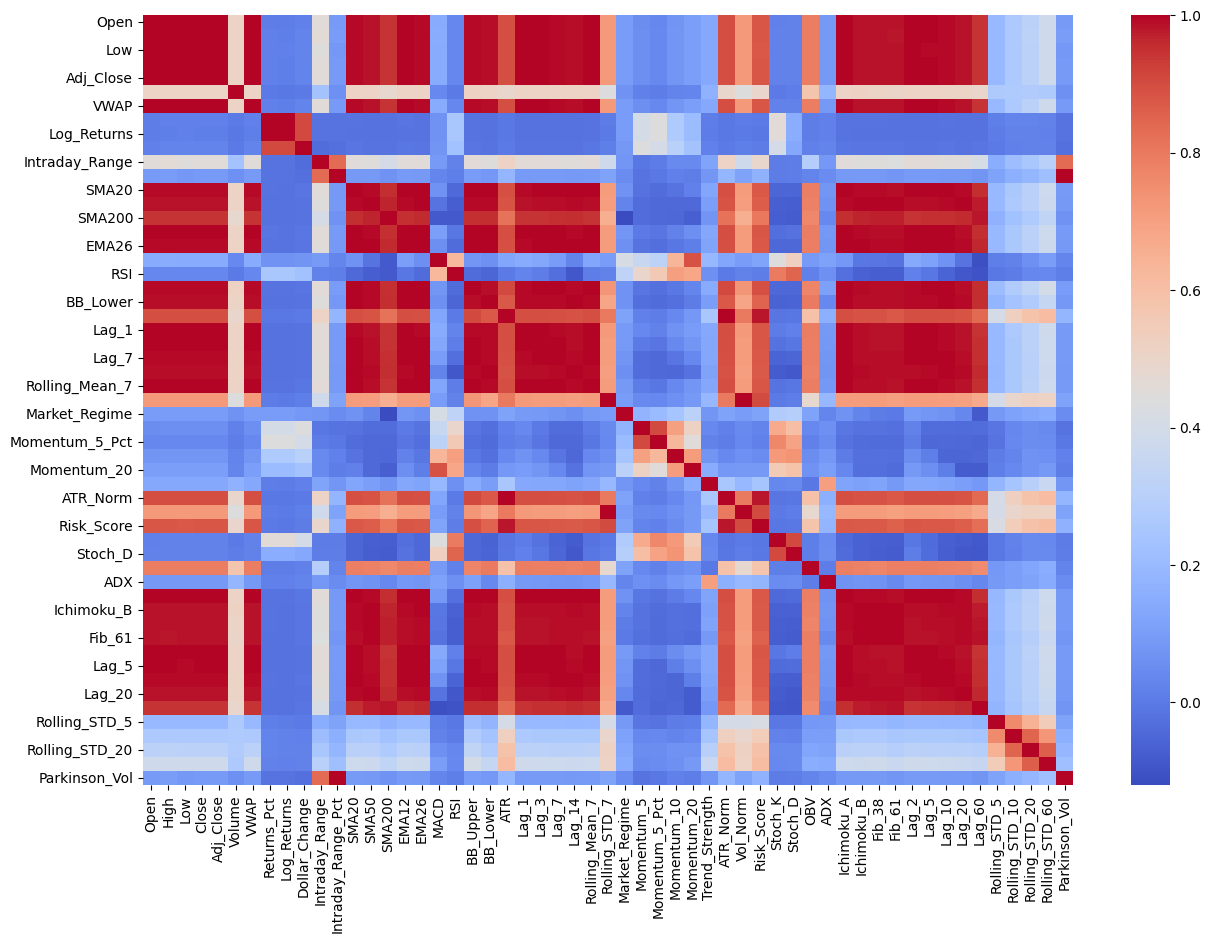

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = (
    ohlcv
    .select_dtypes(include='number')
    .corr()
)

plt.figure(figsize=(15,10))

sns.heatmap(
    corr,
    cmap='coolwarm'
)

plt.show()

In [51]:
corr_matrix = (
    ohlcv
    .select_dtypes(include='number')
    .corr()
    .abs()
)

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

to_drop = [
    column
    for column in upper.columns
    if any(
        upper[column] > 0.95
    )
]

print(to_drop)

['High', 'Low', 'Close', 'Adj_Close', 'VWAP', 'Log_Returns', 'SMA20', 'SMA50', 'SMA200', 'EMA12', 'EMA26', 'BB_Upper', 'BB_Lower', 'Lag_1', 'Lag_3', 'Lag_7', 'Lag_14', 'Rolling_Mean_7', 'ATR_Norm', 'Vol_Norm', 'Risk_Score', 'Ichimoku_A', 'Ichimoku_B', 'Fib_38', 'Fib_61', 'Lag_2', 'Lag_5', 'Lag_10', 'Lag_20', 'Lag_60', 'Parkinson_Vol']


In [52]:
from sklearn.feature_selection import mutual_info_regression

X = ohlcv.drop(
    columns=['Close']
)

X = X.select_dtypes(
    include='number'
)

y = ohlcv['Close']

mi = mutual_info_regression(
    X.fillna(0),
    y
)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi
})

mi_df = mi_df.sort_values(
    'MI_Score',
    ascending=False
)

print(
    mi_df.head(30)
)

           Feature  MI_Score
3        Adj_Close  7.527550
5             VWAP  5.870688
1             High  5.286584
2              Low  5.068140
0             Open  4.788368
21           Lag_1  3.272233
25  Rolling_Mean_7  2.973875
44           Lag_2  2.924908
14           EMA12  2.882826
22           Lag_3  2.750819
40      Ichimoku_A  2.697906
18        BB_Upper  2.576307
15           EMA26  2.536454
11           SMA20  2.517892
45           Lag_5  2.509091
19        BB_Lower  2.484465
42          Fib_38  2.369086
23           Lag_7  2.368722
43          Fib_61  2.345052
41      Ichimoku_B  2.343329
12           SMA50  2.245934
46          Lag_10  2.227226
38             OBV  2.146464
13          SMA200  2.130359
24          Lag_14  2.098404
47          Lag_20  1.991506
48          Lag_60  1.658775
20             ATR  1.195102
33        ATR_Norm  1.194975
35      Risk_Score  1.093156


In [54]:
from sklearn.feature_selection import mutual_info_regression

mi = mutual_info_regression(
    X.fillna(0),
    y
)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI_Score': mi
})

mi_df = mi_df.sort_values(
    'MI_Score',
    ascending=False
)

print(mi_df.head(30))

           Feature  MI_Score
3        Adj_Close  7.526923
5             VWAP  5.870934
1             High  5.286705
2              Low  5.068524
0             Open  4.788372
21           Lag_1  3.272266
25  Rolling_Mean_7  2.973960
44           Lag_2  2.925016
14           EMA12  2.882816
22           Lag_3  2.750754
40      Ichimoku_A  2.698011
18        BB_Upper  2.576347
15           EMA26  2.536528
11           SMA20  2.517935
45           Lag_5  2.509061
19        BB_Lower  2.484477
42          Fib_38  2.369278
23           Lag_7  2.368625
43          Fib_61  2.345432
41      Ichimoku_B  2.343283
12           SMA50  2.245918
46          Lag_10  2.227350
38             OBV  2.146514
13          SMA200  2.130406
24          Lag_14  2.098472
47          Lag_20  1.991491
48          Lag_60  1.658729
20             ATR  1.195051
33        ATR_Norm  1.195010
35      Risk_Score  1.093165


In [55]:
ohlcv = ohlcv.dropna()

print(ohlcv.shape)

(6504, 57)


In [59]:
ohlcv.to_csv(
    "silver_technical_features_v1.csv",
    index=False
)

print(
    "Technical Features Saved Successfully!"
)

Technical Features Saved Successfully!
